# 2.1 Decomposition

2.1 Decomposition: 8 bit planes of the textured cover, PSNR-against-n
reconstruction curve, a constructed linear ramp (standard vs Gray-coded).

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import bit_planes, reconstruct, gray_encode, psnr

ROOT = Path.cwd().parents[1]

In [4]:
cover = np.asarray(Image.open(ROOT / "Images/input/P2/cover_textured.png"))

# --- 8 bit planes ------------------------------------------------------
planes = bit_planes(cover)  # (8, H, W), index 0 = LSB

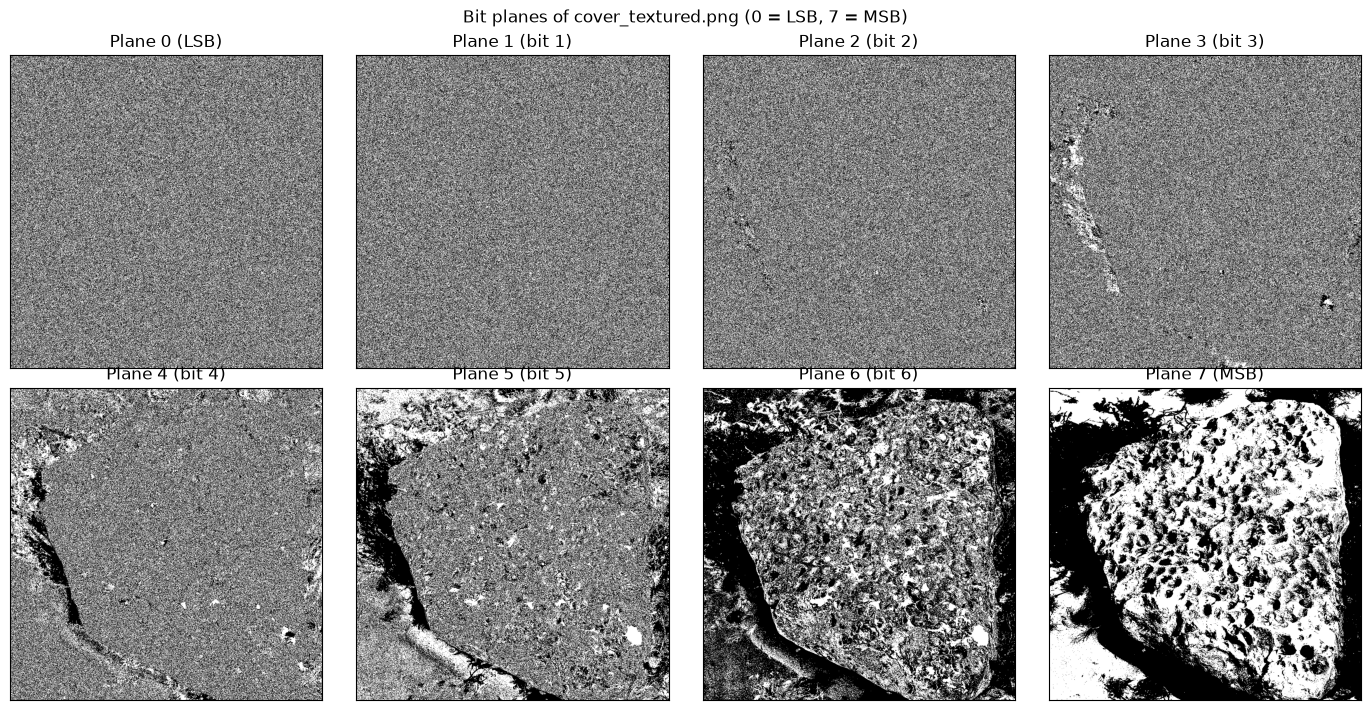

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7.2))
for b in range(8):
    ax = axes[b // 4, b % 4]
    ax.imshow(planes[b], cmap="gray", vmin=0, vmax=1)
    label = "LSB" if b == 0 else ("MSB" if b == 7 else f"bit {b}")
    ax.set_title(f"Plane {b} ({label})")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Bit planes of cover_textured.png (0 = LSB, 7 = MSB)")
fig.tight_layout()
plt.show()

In [6]:
# --- PSNR against n (top-n MSB planes kept) -----------------------------
psnrs = []
for n in range(1, 9):
    rec = reconstruct(planes, n)
    psnrs.append(psnr(rec, cover))
    print(f"n={n} planes kept: PSNR={psnrs[-1]:.2f} dB")

n=1 planes kept: PSNR=11.89 dB
n=2 planes kept: PSNR=16.92 dB
n=3 planes kept: PSNR=23.00 dB
n=4 planes kept: PSNR=29.23 dB
n=5 planes kept: PSNR=35.71 dB
n=6 planes kept: PSNR=42.69 dB
n=7 planes kept: PSNR=51.14 dB
n=8 planes kept: PSNR=inf dB


In [7]:
gains = [psnrs[i] - psnrs[i-1] for i in range(1, len(psnrs)-1)]  # exclude last (inf)
print("per-plane gains (n=1..6 -> n=2..7):", [f"{g:.2f}" for g in gains])
print("mean gain (excluding the inf jump to n=8):", np.mean(gains))

per-plane gains (n=1..6 -> n=2..7): ['5.03', '6.08', '6.23', '6.48', '6.98', '8.45']
mean gain (excluding the inf jump to n=8): 6.541506911895998


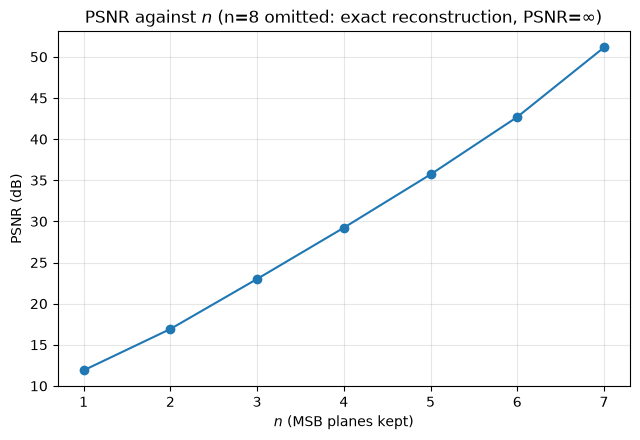

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
finite_n = list(range(1, 8))
finite_psnr = psnrs[:7]
ax.plot(finite_n, finite_psnr, "o-")
ax.set_xlabel("$n$ (MSB planes kept)")
ax.set_ylabel("PSNR (dB)")
ax.set_title("PSNR against $n$ (n=8 omitted: exact reconstruction, PSNR=$\\infty$)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [9]:
# --- Linear ramp: standard binary vs Gray-coded -------------------------
H, W = 256, 512
ramp_row = np.linspace(0, 255, W).astype(np.uint8)
ramp = np.tile(ramp_row, (H, 1))

In [10]:
ramp_planes = bit_planes(ramp)
gray_ramp = gray_encode(ramp)
gray_planes = bit_planes(gray_ramp)

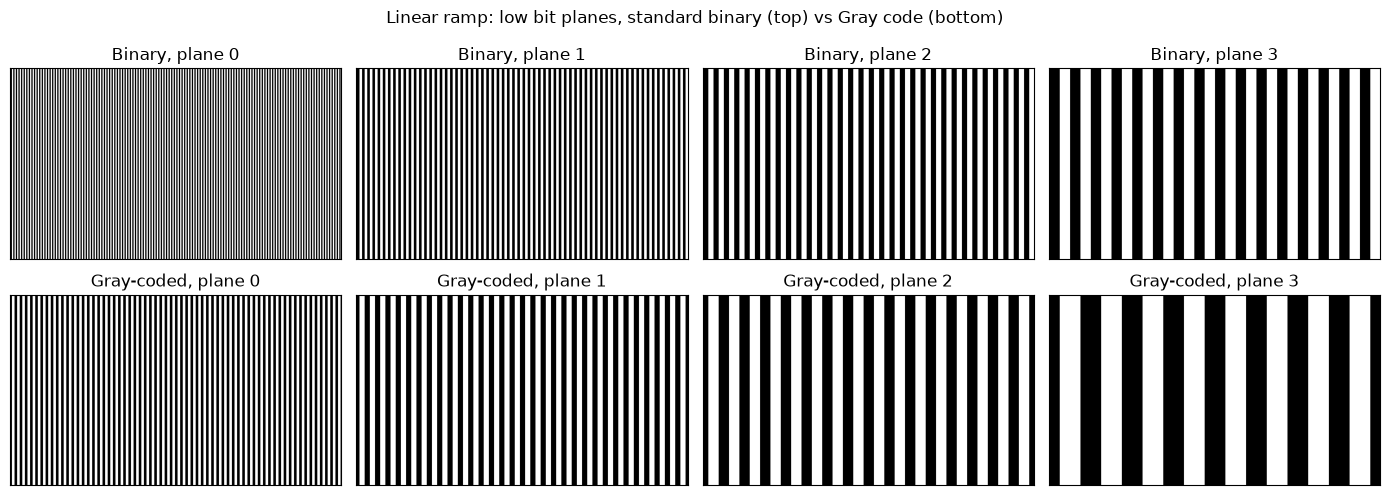

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5.0))
for b in range(4):  # low 4 planes are the interesting/striped ones
    axes[0, b].imshow(ramp_planes[b], cmap="gray", vmin=0, vmax=1, aspect="auto")
    axes[0, b].set_title(f"Binary, plane {b}")
    axes[0, b].set_xticks([]); axes[0, b].set_yticks([])
    axes[1, b].imshow(gray_planes[b], cmap="gray", vmin=0, vmax=1, aspect="auto")
    axes[1, b].set_title(f"Gray-coded, plane {b}")
    axes[1, b].set_xticks([]); axes[1, b].set_yticks([])
fig.suptitle("Linear ramp: low bit planes, standard binary (top) vs Gray code (bottom)")
fig.tight_layout()
plt.show()